# Динамика численности маргариток
Этот скрипт моделирует эволюцию популяций черных и белых маргариток в мире Daisyworld.
Основная цель — наблюдение за процессом саморегуляции и стабилизации популяций (гомеостазом).

In [1]:
using DrWatson
@quickactivate "project"

using Agents, DataFrames, CairoMakie
include(srcdir("daisyworld.jl"))

daisyworld (generic function with 1 method)

## Сбор данных
Мы определяем вспомогательные функции для фильтрации и подсчета агентов в зависимости от их типа (породы).

In [2]:
black(a) = a.breed == :black
white(a) = a.breed == :white

white (generic function with 1 method)

Настраиваем сбор данных: на каждом шаге будет подсчитываться количество черных и белых маргариток.

In [3]:
adata = [(black, count), (white, count)]

2-element Vector{Tuple{Function, typeof(count)}}:
 (Main.var"##230".black, count)
 (Main.var"##230".white, count)

## Моделирование
Инициализируем модель с параметром солнечной светимости (solar_luminosity) равным 1.0.
Запускаем симуляцию на 1000 временных шагов (тиков).

In [4]:
model = daisyworld(; solar_luminosity = 1.0)
agent_df, model_df = run!(model, 1000; adata)

(1001×3 DataFrame
  Row │ time   count_black  count_white 
      │ Int64  Int64        Int64       
──────┼─────────────────────────────────
    1 │     0          180          180
    2 │     1          383          169
    3 │     2          529          232
    4 │     3          563          293
    5 │     4          563          324
    6 │     5          560          336
    7 │     6          556          340
    8 │     7          557          339
  ⋮   │   ⋮         ⋮            ⋮
  995 │   994          486          412
  996 │   995          487          411
  997 │   996          487          410
  998 │   997          485          413
  999 │   998          487          410
 1000 │   999          486          412
 1001 │  1000          488          410
                        986 rows omitted, 0×0 DataFrame)

## Визуализация
Создаем график динамики популяций, аналогичный рисунку 3.2 из лабораторной работы.

In [5]:
figure = Figure(size = (600, 400))
ax = figure[1, 1] = Axis(figure, xlabel = "Время (тики)", ylabel = "Количество маргариток")

Makie.Axis with 0 plots:


Строим линии для черных и белых маргариток.

In [6]:
blackl = lines!(ax, agent_df[!, :time], agent_df[!, :count_black], color = :black)
whitel = lines!(ax, agent_df[!, :time], agent_df[!, :count_white], color = :orange)

Makie.Lines{Tuple{Vector{GeometryBasics.Point{2, Float64}}}}

Добавляем легенду в правой части графика (позиция [1, 2]).

In [7]:
Legend(figure[1, 2], [blackl, whitel], ["Черные", "Белые"], labelsize = 12)

Makie.Legend()

Отображение итогового графика:

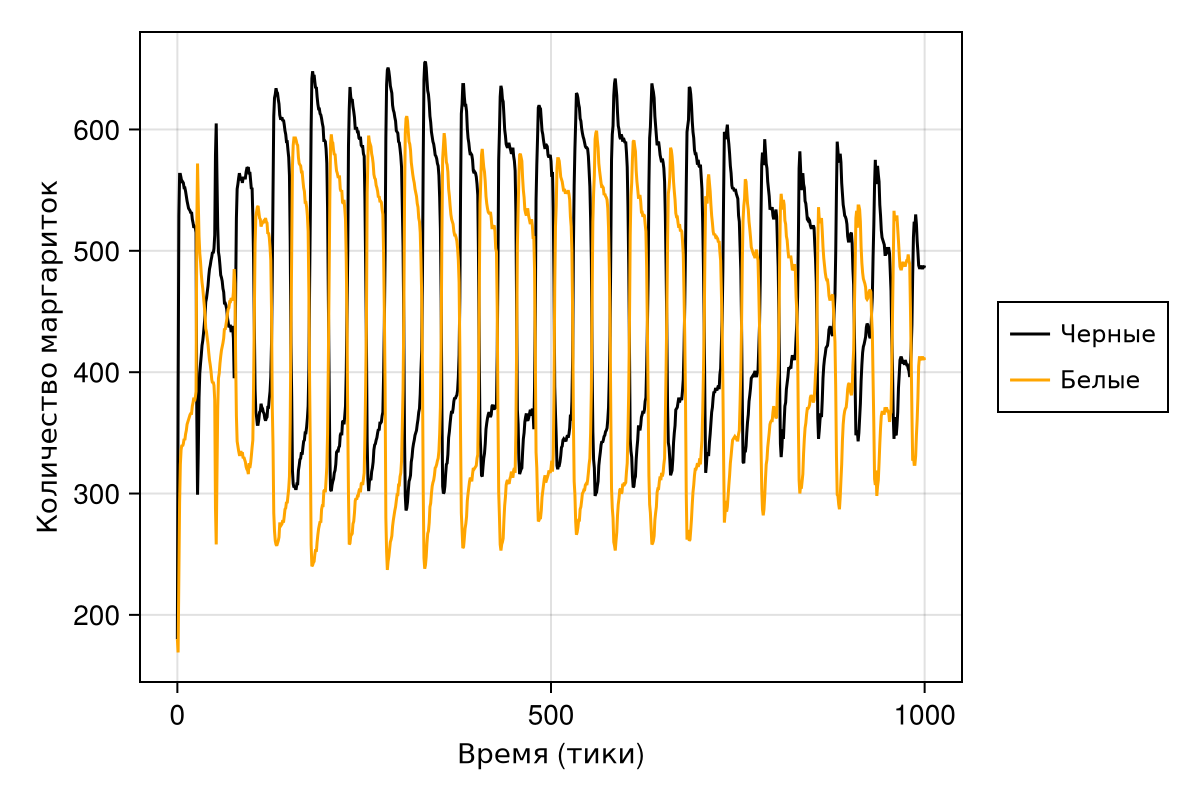

In [8]:
figure

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*